## **Business Task :**
 Analyze smart device usage data from non-Bellabeat devices to uncover behavioral trends, then apply those insights to one Bellabeat product and deliver actionable marketing strategy recommendations to the executive team.



Analyst Role : Junior Data Analyst

Team : Bellabeat Marketing Analytics

Sponsor : Urska Srsen, Chief Creative Officer

Dataset : FitBit Fitness Tracker Data (Kaggle, CC0)

Framework :Ask → Prepare → Process → Analyze → Share → Act

Goal : Unlock smart device growth opportunities for Bellabeat



# **1. Ask Phase**

What are some trends in smart device usage?

How could these trends apply to Bellabeat customers?

How could these trends help influence Bellabeat marketing strategy?


### KeyStake holders

Urska Srsen – Cofounder & Chief Creative Officer (primary sponsor)

Sando Mur – Mathematician & Cofounder, key executive member

Bellabeat Marketing Analytics Team – peer collaborators


### Scope Of work [link text](https://docs.google.com/document/d/1FBuIm6f8A6hbxAbY_hN50f9nKBG8rAbcqe1b1mgoWHI/edit?usp=sharing)


# **2. Prepare Phace**

Connecting the notebook with kaggle for not dwownload the all files in pc.

In [ ]:
import os
import json

kaggle_credentials = {
    "username": "vanshvans",
    "key": "KGAT_37bbd4ce8a2080c8a897f6a55b1d4d50"
}

os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_credentials, f)
os.chmod("/root/.kaggle/kaggle.json", 0o600)
print("✅ Credentials set!")

✅ Credentials set!


In [ ]:
os.system("pip install kaggle -q")
os.system("kaggle datasets download -d arashnic/fitbit --unzip -p /content/fitbit")
print("✅ Downloaded!")

✅ Downloaded!


In [ ]:
import glob

all_files = glob.glob("/content/fitbit/*.csv")
for f in sorted(all_files):
    print(f.replace("/content/fitbit/", ""))


Paths of the files in the kaggle

In [ ]:
import os

for root, dirs, files in os.walk("/content/fitbit"):
    for file in files:
        print(os.path.join(root, file))


/content/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/heartrate_seconds_merged.csv
/content/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/sleepDay_merged.csv
/content/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/weightLogInfo_merged.csv
/content/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/dailyIntensities_merged.csv
/content/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/minuteSleep_merged.csv
/content/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/minuteCaloriesNarrow_merged.csv
/content/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/dailyActivity_merged.csv
/content/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/minuteIntensitiesWide_merged.csv
/content/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/minuteMETsNarrow_merged.csv
/content/fitbit/mturkfitbit_

In [ ]:
import glob

# Search in ALL subfolders recursively
all_files = glob.glob("/content/fitbit/**/*.csv", recursive=True)

for f in sorted(all_files):
    print(f)

/content/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/dailyActivity_merged.csv
/content/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/heartrate_seconds_merged.csv
/content/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/hourlyCalories_merged.csv
/content/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/hourlyIntensities_merged.csv
/content/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/hourlySteps_merged.csv
/content/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/minuteCaloriesNarrow_merged.csv
/content/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/minuteIntensitiesNarrow_merged.csv
/content/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/minuteMETsNarrow_merged.csv
/content/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/minuteSleep_merged.csv
/content/fitbit/mturk

All the data files with there shape

In [ ]:
import pandas as pd

dataframes = {}
for filepath in sorted(all_files):
    name = os.path.basename(filepath).replace(".csv", "")
    dataframes[name] = pd.read_csv(filepath)
    print(f"✅ {name} → {dataframes[name].shape}")

✅ dailyActivity_merged → (457, 15)
✅ heartrate_seconds_merged → (1154681, 3)
✅ hourlyCalories_merged → (24084, 3)
✅ hourlyIntensities_merged → (24084, 4)
✅ hourlySteps_merged → (24084, 3)
✅ minuteCaloriesNarrow_merged → (1445040, 3)
✅ minuteIntensitiesNarrow_merged → (1445040, 3)
✅ minuteMETsNarrow_merged → (1445040, 3)
✅ minuteSleep_merged → (198559, 4)
✅ minuteStepsNarrow_merged → (1445040, 3)
✅ weightLogInfo_merged → (33, 8)
✅ dailyActivity_merged → (940, 15)
✅ dailyCalories_merged → (940, 3)
✅ dailyIntensities_merged → (940, 10)
✅ dailySteps_merged → (940, 3)
✅ heartrate_seconds_merged → (2483658, 3)
✅ hourlyCalories_merged → (22099, 3)
✅ hourlyIntensities_merged → (22099, 4)
✅ hourlySteps_merged → (22099, 3)
✅ minuteCaloriesNarrow_merged → (1325580, 3)
✅ minuteCaloriesWide_merged → (21645, 62)
✅ minuteIntensitiesNarrow_merged → (1325580, 3)
✅ minuteIntensitiesWide_merged → (21645, 62)
✅ minuteMETsNarrow_merged → (1325580, 3)
✅ minuteSleep_merged → (188521, 4)
✅ minuteStepsNarrow_m

All files with how many rows and columns.

In [ ]:
print(f"Total files loaded: {len(dataframes)}\n")
print(f"{'File':<45} {'Rows':>8} {'Cols':>5}")
print("-" * 62)
for name, df in dataframes.items():
    print(f"{name:<45} {df.shape[0]:>8} {df.shape[1]:>5}")

Total files loaded: 18

File                                              Rows  Cols
--------------------------------------------------------------
dailyActivity_merged                               940    15
heartrate_seconds_merged                       2483658     3
hourlyCalories_merged                            22099     3
hourlyIntensities_merged                         22099     4
hourlySteps_merged                               22099     3
minuteCaloriesNarrow_merged                    1325580     3
minuteIntensitiesNarrow_merged                 1325580     3
minuteMETsNarrow_merged                        1325580     3
minuteSleep_merged                              188521     4
minuteStepsNarrow_merged                       1325580     3
weightLogInfo_merged                                67     8
dailyCalories_merged                               940     3
dailyIntensities_merged                            940    10
dailySteps_merged                                  940     

In [ ]:
df_activity = dataframes["dailyActivity_merged"]
df_sleep    = dataframes["sleepDay_merged"]

print("✅ Daily Activity shape:", df_activity.shape)
print("✅ Sleep Day shape:", df_sleep.shape)

✅ Daily Activity shape: (940, 15)
✅ Sleep Day shape: (413, 5)


In [ ]:
print(df_activity.dtypes)
print(df_sleep.dtypes)

Id                            int64
ActivityDate                 object
TotalSteps                    int64
TotalDistance               float64
TrackerDistance             float64
LoggedActivitiesDistance    float64
VeryActiveDistance          float64
ModeratelyActiveDistance    float64
LightActiveDistance         float64
SedentaryActiveDistance     float64
VeryActiveMinutes             int64
FairlyActiveMinutes           int64
LightlyActiveMinutes          int64
SedentaryMinutes              int64
Calories                      int64
dtype: object
Id                     int64
SleepDay              object
TotalSleepRecords      int64
TotalMinutesAsleep     int64
TotalTimeInBed         int64
dtype: object



1.  Data is collected successfully from kaggle to google collab notebook via api.
2. Almost all  columns data set is right but have to change the date columns datatype.
3. In the sleep data set data is long and in daily activities data is wide and long.
4. To some extent data is sampling bias because its not covers whole population.
5  Data follows all data ethics rules its collected by the permission of 30 people.


# **Process Phase**

Cheaking the data integrity

In [ ]:
print(df_activity.isnull().sum())
print(df_sleep.isnull().sum())

Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
dtype: int64
Id                    0
SleepDay              0
TotalSleepRecords     0
TotalMinutesAsleep    0
TotalTimeInBed        0
dtype: int64


In [ ]:
print(df_activity.duplicated().sum())
print(df_sleep.duplicated().sum())


0
3


Removing the duplicates from sleep columns

In [ ]:
print(df_sleep.drop_duplicates(inplace=True))

None


In [ ]:
print(df_sleep.duplicated().sum())

0


Verifing columns datatypes

In [ ]:
print(df_activity.dtypes)
print(df_sleep.dtypes)
print(df_activity.head)
print(df_sleep.head)

Id                            int64
ActivityDate                 object
TotalSteps                    int64
TotalDistance               float64
TrackerDistance             float64
LoggedActivitiesDistance    float64
VeryActiveDistance          float64
ModeratelyActiveDistance    float64
LightActiveDistance         float64
SedentaryActiveDistance     float64
VeryActiveMinutes             int64
FairlyActiveMinutes           int64
LightlyActiveMinutes          int64
SedentaryMinutes              int64
Calories                      int64
dtype: object
Id                     int64
SleepDay              object
TotalSleepRecords      int64
TotalMinutesAsleep     int64
TotalTimeInBed         int64
dtype: object
<bound method NDFrame.head of              Id ActivityDate  TotalSteps  TotalDistance  TrackerDistance  \
0    1503960366    4/12/2016       13162       8.500000         8.500000   
1    1503960366    4/13/2016       10735       6.970000         6.970000   
2    1503960366    4/14/2016 

In [ ]:
df_activity['ActivityDate'] = pd.to_datetime(df_activity['ActivityDate'])

In [ ]:
print(df_activity.isnull().sum())
print(df_sleep.isnull().sum())

Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
dtype: int64
Id                    0
SleepDay              0
TotalSleepRecords     0
TotalMinutesAsleep    0
TotalTimeInBed        0
dtype: int64


In [ ]:
print(df_activity.describe())
print(df_sleep.describe())

                 Id                   ActivityDate    TotalSteps  \
count  9.400000e+02                            940    940.000000   
mean   4.855407e+09  2016-04-26 06:53:37.021276672   7637.910638   
min    1.503960e+09            2016-04-12 00:00:00      0.000000   
25%    2.320127e+09            2016-04-19 00:00:00   3789.750000   
50%    4.445115e+09            2016-04-26 00:00:00   7405.500000   
75%    6.962181e+09            2016-05-04 00:00:00  10727.000000   
max    8.877689e+09            2016-05-12 00:00:00  36019.000000   
std    2.424805e+09                            NaN   5087.150742   

       TotalDistance  TrackerDistance  LoggedActivitiesDistance  \
count     940.000000       940.000000                940.000000   
mean        5.489702         5.475351                  0.108171   
min         0.000000         0.000000                  0.000000   
25%         2.620000         2.620000                  0.000000   
50%         5.245000         5.245000               

Removing extre spaces

In [ ]:
df_activity = df_activity.rename(columns=str.strip).applymap(lambda x: x.strip() if isinstance(x, str) else x)
df_sleep = df_sleep.rename(columns=str.strip).applymap(lambda x: x.strip() if isinstance(x, str) else x)

print("✅ Done!")

✅ Done!


/tmp/ipykernel_3275/541315454.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_activity = df_activity.rename(columns=str.strip).applymap(lambda x: x.strip() if isinstance(x, str) else x)
/tmp/ipykernel_3275/541315454.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_sleep = df_sleep.rename(columns=str.strip).applymap(lambda x: x.strip() if isinstance(x, str) else x)


1. Data integrity done.
2. Check for duplicate rows.
3. Verify column data types are correct.
4. Handle null / missing values.
5. Standardize date and time formats.
6. Remove irrelevant columns.
7. Validate min / max values are within range.



# **Analysis Phase**

Basic Staristics

In [ ]:
print("Unique users in Activity :", df_activity["Id"].nunique())
print("Unique users in Sleep    :", df_sleep["Id"].nunique())

Unique users in Activity : 33
Unique users in Sleep    : 24


In [ ]:
print("📊 Activity Summary Statistics")
df_activity[["TotalSteps", "TotalDistance",
             "VeryActiveMinutes", "FairlyActiveMinutes",
             "LightlyActiveMinutes", "SedentaryMinutes",
             "Calories"]].describe().round(2)

📊 Activity Summary Statistics


,TotalSteps,TotalDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
count,940.00,940.00,940.00,940.00,940.00,940.00,940.00
mean,7637.91,5.49,21.16,13.56,192.81,991.21,2303.61
std,5087.15,3.92,32.84,19.99,109.17,301.27,718.17
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,3789.75,2.62,0.00,0.00,127.00,729.75,1828.50
50%,7405.50,5.24,4.00,6.00,199.00,1057.50,2134.00
75%,10727.00,7.71,32.00,19.00,264.00,1229.50,2793.25
max,36019.00,28.03,210.00,143.00,518.00,1440.00,4900.00


In [ ]:
print("😴 Sleep Summary Statistics")
df_sleep[["TotalSleepRecords",
          "TotalMinutesAsleep",
          "TotalTimeInBed"]].describe().round(2)

😴 Sleep Summary Statistics


,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
count,410.00,410.00,410.00
mean,1.12,419.17,458.48
std,0.35,118.64,127.46
min,1.00,58.00,61.00
25%,1.00,361.00,403.75
50%,1.00,432.50,463.00
75%,1.00,490.00,526.00
max,3.00,796.00,961.00


In [ ]:
avg_activity = df_activity.groupby("Id").agg(
    Avg_Steps        = ("TotalSteps", "mean"),
    Avg_Calories     = ("Calories", "mean"),
    Avg_Sedentary    = ("SedentaryMinutes", "mean"),
    Avg_VeryActive   = ("VeryActiveMinutes", "mean")
).round(2).reset_index()

print("📊 Average Activity Per User")
avg_activity.head(10)

📊 Average Activity Per User


,Id,Avg_Steps,Avg_Calories,Avg_Sedentary,Avg_VeryActive
0,1503960366,12116.74,1816.42,848.16,38.71
1,1624580081,5743.90,1483.35,1257.74,8.68
2,1644430081,7282.97,2811.30,1161.87,9.57
3,1844505072,2580.06,1573.48,1206.61,0.13
4,1927972279,916.13,2172.81,1317.42,1.32
5,2022484408,11370.65,2509.97,1112.58,36.29
6,2026352035,5566.87,1540.65,689.42,0.10
7,2320127002,4716.87,1724.16,1220.10,1.35
8,2347167796,9519.67,2043.44,687.17,13.50
9,2873212765,7555.77,1916.97,1097.19,14.10


In [ ]:
avg_sleep = df_sleep.groupby("Id").agg(
    Avg_MinutesAsleep = ("TotalMinutesAsleep", "mean"),
    Avg_TimeInBed     = ("TotalTimeInBed", "mean")
).round(2).reset_index()

# Convert minutes to hours for readability
avg_sleep["Avg_HoursAsleep"] = (avg_sleep["Avg_MinutesAsleep"] / 60).round(2)
avg_sleep["Avg_HoursInBed"]  = (avg_sleep["Avg_TimeInBed"] / 60).round(2)

print("😴 Average Sleep Per User")
avg_sleep.head(10)

😴 Average Sleep Per User


,Id,Avg_MinutesAsleep,Avg_TimeInBed,Avg_HoursAsleep,Avg_HoursInBed
0,1503960366,360.28,383.20,6.00,6.39
1,1644430081,294.00,346.00,4.90,5.77
2,1844505072,652.00,961.00,10.87,16.02
3,1927972279,417.00,437.80,6.95,7.30
4,2026352035,506.18,537.64,8.44,8.96
5,2320127002,61.00,69.00,1.02,1.15
6,2347167796,446.80,491.33,7.45,8.19
7,3977333714,293.64,461.14,4.89,7.69
8,4020332650,349.38,379.75,5.82,6.33
9,4319703577,476.65,501.96,7.94,8.37


In [ ]:
def classify_user(steps):
    if steps < 5000:
        return "Sedentary"
    elif steps < 7500:
        return "Lightly Active"
    elif steps < 10000:
        return "Fairly Active"
    else:
        return "Very Active"

avg_activity["User_Type"] = avg_activity["Avg_Steps"].apply(classify_user)

print("📊 User Activity Classification")
print(avg_activity["User_Type"].value_counts())

📊 User Activity Classification
User_Type
Lightly Active    9
Fairly Active     9
Sedentary         8
Very Active       7
Name: count, dtype: int64


In [ ]:
df_activity["ActivityDate"] = pd.to_datetime(df_activity["ActivityDate"])
df_sleep["SleepDay"]        = pd.to_datetime(df_sleep["SleepDay"])

df_sleep_clean = df_sleep.rename(columns={"SleepDay": "ActivityDate"})

df_merged = pd.merge(df_activity, df_sleep_clean, on=["Id", "ActivityDate"], how="inner")

print(f"✅ Merged table shape: {df_merged.shape}")
df_merged.head()

✅ Merged table shape: (410, 18)


/tmp/ipykernel_3275/3245098719.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_sleep["SleepDay"]        = pd.to_datetime(df_sleep["SleepDay"])


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,1,327,346
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797,2,384,407
2,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745,1,412,442
3,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863,2,340,367
4,1503960366,2016-04-17,9705,6.48,6.48,0.0,3.19,0.78,2.51,0.0,38,20,164,539,1728,1,700,712


# **Share Phase (Visualization)**

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.family"]    = "sans-serif"

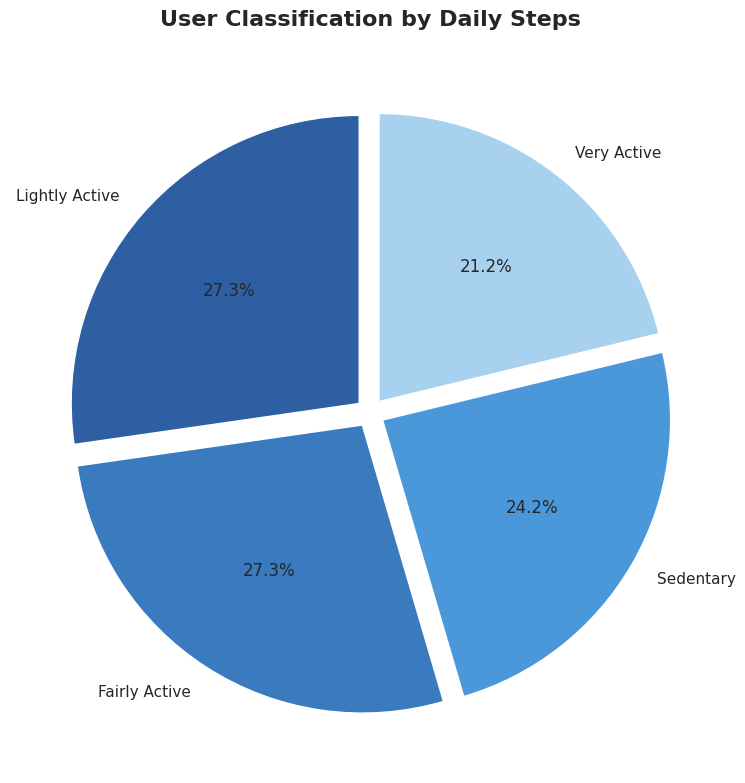

In [ ]:
# @title
user_type_counts = avg_activity["User_Type"].value_counts()

colors = ["#2E5FA3", "#3A7ABF", "#4A97D9", "#A8D1F0"]

plt.figure(figsize=(8, 8))
plt.pie(user_type_counts,
        labels    = user_type_counts.index,
        autopct   = "%1.1f%%",
        colors    = colors,
        startangle= 90,
        explode   = [0.05] * len(user_type_counts))

plt.title("User Classification by Daily Steps", fontsize=16, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("user_classification.png", dpi=150, bbox_inches="tight")
plt.show()

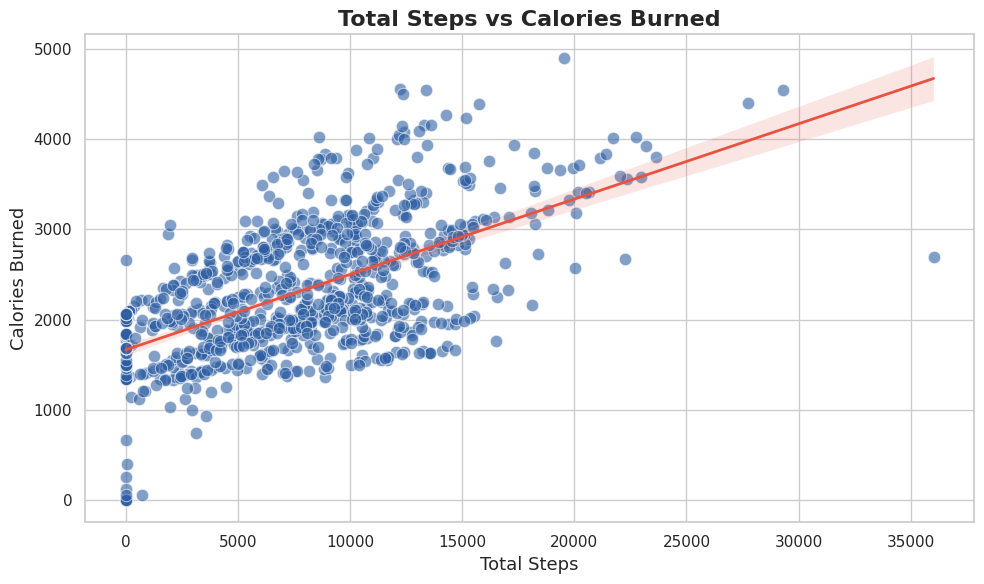

In [ ]:
# @title
plt.figure(figsize=(10, 6))
sns.scatterplot(data = df_activity,
                x    = "TotalSteps",
                y    = "Calories",
                alpha= 0.6,
                color= "#2E5FA3",
                s    = 80)

# Add trend line
sns.regplot(data      = df_activity,
            x         = "TotalSteps",
            y         = "Calories",
            scatter   = False,
            color     = "#E8533F",
            line_kws  = {"linewidth": 2})

plt.title("Total Steps vs Calories Burned",  fontsize=16, fontweight="bold")
plt.xlabel("Total Steps",                    fontsize=13)
plt.ylabel("Calories Burned",                fontsize=13)
plt.tight_layout()
plt.savefig("steps_vs_calories.png", dpi=150, bbox_inches="tight")
plt.show()

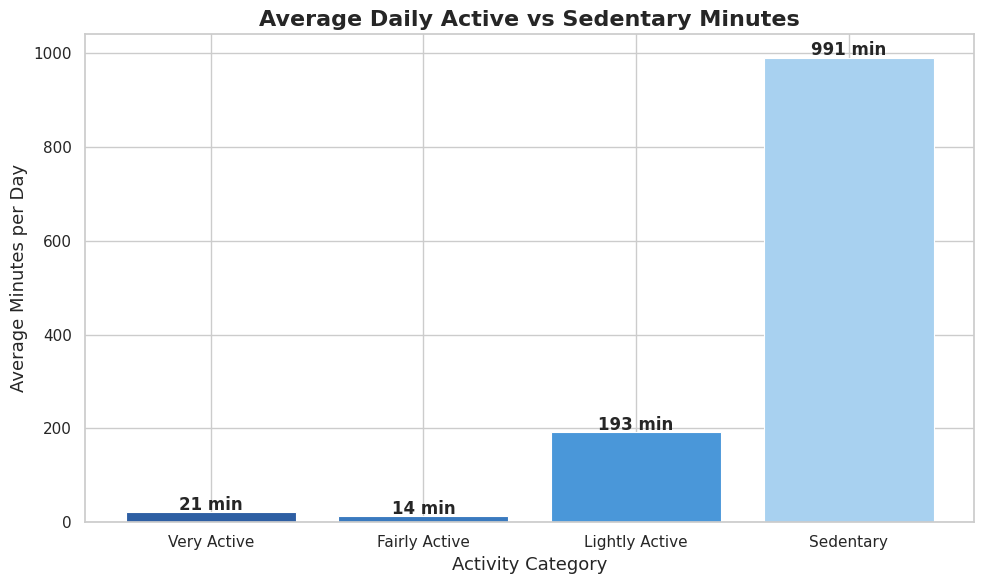

In [ ]:
# @title
minutes = pd.DataFrame({
    "Category": ["Very Active", "Fairly Active", "Lightly Active", "Sedentary"],
    "Minutes"  : [
        df_activity["VeryActiveMinutes"].mean(),
        df_activity["FairlyActiveMinutes"].mean(),
        df_activity["LightlyActiveMinutes"].mean(),
        df_activity["SedentaryMinutes"].mean()
    ]
})

colors = ["#2E5FA3", "#3A7ABF", "#4A97D9", "#A8D1F0"]

plt.figure(figsize=(10, 6))
bars = plt.bar(minutes["Category"], minutes["Minutes"], color=colors, edgecolor="white", linewidth=0.8)

# Add value labels on bars
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5,
             f"{bar.get_height():.0f} min",
             ha="center", fontsize=12, fontweight="bold")

plt.title("Average Daily Active vs Sedentary Minutes", fontsize=16, fontweight="bold")
plt.xlabel("Activity Category",                        fontsize=13)
plt.ylabel("Average Minutes per Day",                  fontsize=13)
plt.tight_layout()
plt.savefig("active_vs_sedentary.png", dpi=150, bbox_inches="tight")
plt.show()

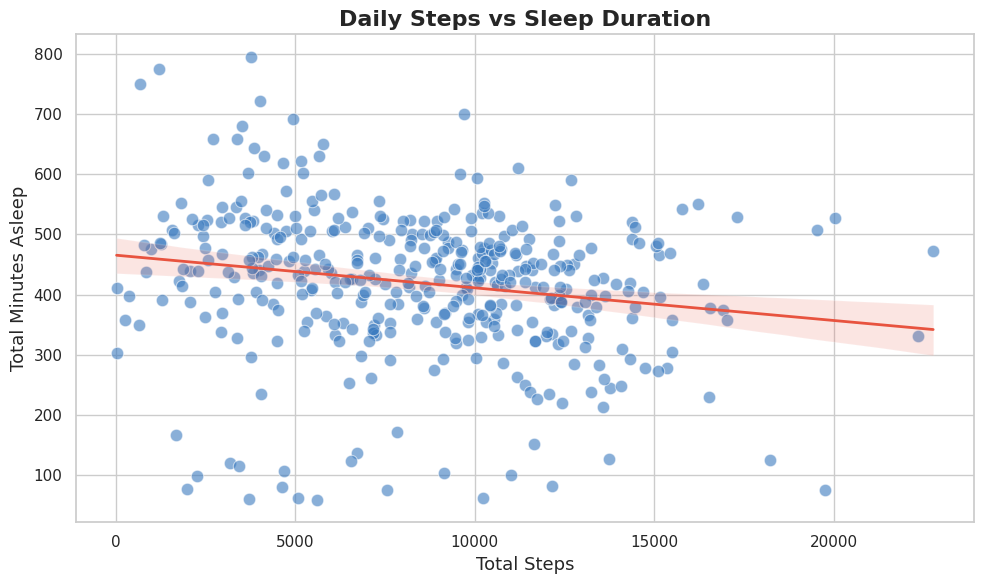

In [ ]:
# @title
plt.figure(figsize=(10, 6))
sns.scatterplot(data  = df_merged,
                x     = "TotalSteps",
                y     = "TotalMinutesAsleep",
                alpha = 0.6,
                color = "#3A7ABF",
                s     = 80)

sns.regplot(data     = df_merged,
            x        = "TotalSteps",
            y        = "TotalMinutesAsleep",
            scatter  = False,
            color    = "#E8533F",
            line_kws = {"linewidth": 2})

plt.title("Daily Steps vs Sleep Duration",  fontsize=16, fontweight="bold")
plt.xlabel("Total Steps",                   fontsize=13)
plt.ylabel("Total Minutes Asleep",          fontsize=13)
plt.tight_layout()
plt.savefig("steps_vs_sleep.png", dpi=150, bbox_inches="tight")
plt.show()

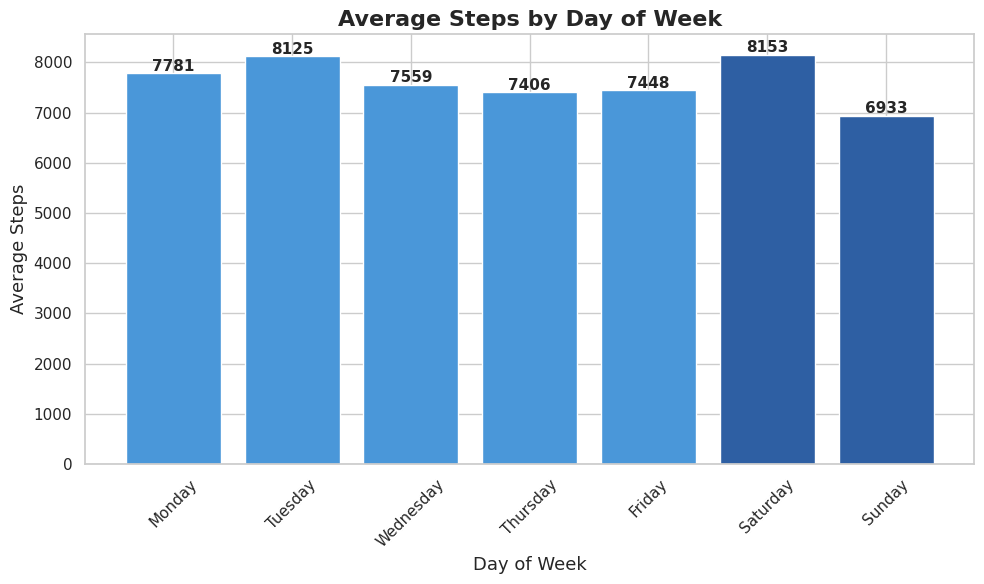

In [ ]:
# @title
df_activity["DayOfWeek"] = df_activity["ActivityDate"].dt.day_name()

day_order = ["Monday", "Tuesday", "Wednesday",
             "Thursday", "Friday", "Saturday", "Sunday"]

avg_steps_day = df_activity.groupby("DayOfWeek")["TotalSteps"].mean().reindex(day_order)

plt.figure(figsize=(10, 6))
bars = plt.bar(avg_steps_day.index,
               avg_steps_day.values,
               color     = ["#2E5FA3" if d in ["Saturday", "Sunday"]
                             else "#4A97D9" for d in day_order],
               edgecolor = "white")

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50,
             f"{bar.get_height():.0f}",
             ha="center", fontsize=11, fontweight="bold")

plt.title("Average Steps by Day of Week",  fontsize=16, fontweight="bold")
plt.xlabel("Day of Week",                  fontsize=13)
plt.ylabel("Average Steps",                fontsize=13)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("steps_by_day.png", dpi=150, bbox_inches="tight")
plt.show()

## Trend Found
1 High Sedentary Behavior — 77.7% of users are sedentary with an average of 991 min/day inactive.

2 Low Active Minutes — Users average only 21 very active minutes per day.

3 Drive Calories — Clear positive relationship between daily steps and calories burned.

4 Weekend Inactivity — Sunday is consistently the least active day (6,933 avg steps).

5 Activity vs Sleep Tradeoff — More active users tend to get slightly less sleep.